### Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import json

In [2]:
# -----------------------------
# IEEE one-column settings
# -----------------------------
plt.rcParams.update({
    "text.usetex": True,              # Usa o LaTeX para renderizar os textos
    "font.family": "serif",           # Define a família da fonte como serif
    "font.serif": ["Times"],          # Especifica a fonte Times
    "axes.labelsize": 9,              # Tamanho da fonte dos eixos (o padrão do texto é 9pt)
    "font.size": 9,                   # Tamanho da fonte geral
    "legend.fontsize": 9,             # Legendas menores (comum em papers)
    "xtick.labelsize": 9,             # Tamanho dos números no eixo X
    "ytick.labelsize": 9,             # Tamanho dos números no eixo Y
    # Caso use símbolos matemáticos, garante que a fonte matemática também seja Times-like
    "text.latex.preamble": r"\usepackage{mathptmx}" 
})

### Read Data

In [3]:
# Carregar os arquivos CSV
df1 = pd.read_csv("../../data/fixed_prompts_sabia_generated_recommendations.csv")
df2 = pd.read_csv("../../data/fixed_prompts_gemma_generated_recommendations.csv")
df3 = pd.read_csv("../../data/fixed_prompts_generated_recommendations.csv")

# Drop sabia model from df3
df3 = df3[df3['modelo'] != 'sabia-4']

# df = pd.read_csv("../../data/fixed_prompts_gemma_generated_recommendations.csv")
df = pd.concat([df1, df2, df3], ignore_index=True)

# Remover colunas temperatura e repetição
df = df.drop(columns=["temperatura", "repeticao"])

In [4]:
# Check indexes are unique
assert df.index.is_unique, "Indexes are not unique!"

# Check if there are any duplicates (do not consider the index)
assert df.duplicated().sum()==0, "There are duplicates!"

In [5]:
df.head(5)

,modelo,system_prompt,user_prompt,system_prompt_text,user_prompt_text,sended_system_prompt_text,sended_user_prompt_text,enviar_apenas_como_user,enviar_system_prompt_vazio,resposta_raw
0,sabia-4,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,Eu estou no último ano do ensino médio e sou u...,"Eu me interesso por Linguagens, Códigos e suas...",NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Letras"",\n ..."
1,sabia-4,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Ciencias_Humanas_Tecnol...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Ciências Humanas e suas Te...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciências so..."
2,sabia-4,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Ciencias_Natureza_Tecno...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Ciências da Natureza e sua...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Biologia"",\..."
3,sabia-4,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Matematica_Tecnologias'...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Matemática e suas Tecnolog...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Matemática""..."
4,sabia-4,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'sem_interesse_declarado...,Eu estou no último ano do ensino médio e sou u...,Quais áreas de formação em cursos de graduação...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciência da ..."


### Get Gender and Color from System Prompt

In [6]:
df['system_prompt'].value_counts()

system_prompt
{'marcador_codigo': 'masculino', 'marcador_descricao': ' e sou um homem', 'marcador': ' e sou um homem'}                                                                40
{'marcador_codigo': 'feminino', 'marcador_descricao': ' e sou uma mulher', 'marcador': ' e sou uma mulher'}                                                             40
{'marcador_codigo': 'masculino_branca', 'marcador_descricao': ' e sou um homem de cor ou raça branca', 'marcador': ' e sou um homem de cor ou raça branca'}             40
{'marcador_codigo': 'masculino_preta', 'marcador_descricao': ' e sou um homem de cor ou raça preta', 'marcador': ' e sou um homem de cor ou raça preta'}                40
{'marcador_codigo': 'masculino_parda', 'marcador_descricao': ' e sou um homem de cor ou raça parda', 'marcador': ' e sou um homem de cor ou raça parda'}                40
{'marcador_codigo': 'masculino_amarela', 'marcador_descricao': ' e sou um homem de cor ou raça amarela', 'marcador': ' e sou um hom

In [7]:
# Separar o dicionário da coluna de system prompt
def extract_system_prompt(system_prompt):
    try:
        # Tentar converter a string em um dicionário
        system_prompt_dict = json.loads(system_prompt.replace("'", '"'))
        # Se não tiver marcador descrição, tem um erro
        prompt = system_prompt_dict["marcador_descricao"]
        return prompt
    except Exception as err:
        print("Erro: {err}")
        return err
    
def extract_gender(nome):
    if "homem" in nome:
        return "masculino"
    elif "mulher" in nome:
        return "feminino"
    else:
        return "sem_genero_declarado"
    
def extract_color(nome):
    cores = ["branca", "preta", "parda", "amarela", "indígena"]
    for cor in cores:
        if cor in nome:
            return cor
    return "sem_cor_declarada"
    
df["system_prompt"] = df["system_prompt"].apply(extract_system_prompt)
df["genero"] = df["system_prompt"].apply(extract_gender)
df["cor"] = df["system_prompt"].apply(extract_color)

df.head(5)

,modelo,system_prompt,user_prompt,system_prompt_text,user_prompt_text,sended_system_prompt_text,sended_user_prompt_text,enviar_apenas_como_user,enviar_system_prompt_vazio,resposta_raw,genero,cor
0,sabia-4,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,Eu estou no último ano do ensino médio e sou u...,"Eu me interesso por Linguagens, Códigos e suas...",NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Letras"",\n ...",masculino,sem_cor_declarada
1,sabia-4,e sou um homem,{'disciplina_codigo': 'Ciencias_Humanas_Tecnol...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Ciências Humanas e suas Te...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciências so...",masculino,sem_cor_declarada
2,sabia-4,e sou um homem,{'disciplina_codigo': 'Ciencias_Natureza_Tecno...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Ciências da Natureza e sua...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Biologia"",\...",masculino,sem_cor_declarada
3,sabia-4,e sou um homem,{'disciplina_codigo': 'Matematica_Tecnologias'...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Matemática e suas Tecnolog...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Matemática""...",masculino,sem_cor_declarada
4,sabia-4,e sou um homem,{'disciplina_codigo': 'sem_interesse_declarado...,Eu estou no último ano do ensino médio e sou u...,Quais áreas de formação em cursos de graduação...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada


In [8]:
# Sanity check: check wheter the gender is in the sended_user_prompt_text column
def check_gender_in_prompt(row):
    prompt_text = row['sended_user_prompt_text'].lower()
    gender = row['genero']
    if gender == "masculino" and "homem" in prompt_text:
        return True
    elif gender == "feminino" and "mulher" in prompt_text:
        return True
    elif gender == "sem_genero_declarado" and "homem" not in prompt_text and "mulher" not in prompt_text:
        return True
    return False

def check_color_in_prompt(row):
    prompt_text = row['sended_user_prompt_text'].lower()
    color = row['cor']
    if color == "branca" and "branca" in prompt_text:
        return True
    elif color == "preta" and "preta" in prompt_text:
        return True
    elif color == "parda" and "parda" in prompt_text:
        return True
    elif color == "amarela" and "amarela" in prompt_text:
        return True
    elif color == "indígena" and "indígena" in prompt_text:
        return True
    elif color == "sem_cor_declarada" and all(cor not in prompt_text for cor in ["branca", "preta", "parda", "amarela", "indígena"]):
        return True
    return False

In [9]:
# Check if the gender and color extracted from the system prompt is present in the sended_user_prompt_text
print(df.apply(check_gender_in_prompt, axis=1).value_counts())
print(df.apply(check_color_in_prompt, axis=1).value_counts())

True    720
Name: count, dtype: int64
True    720
Name: count, dtype: int64


### Get Interest from User Prompt

In [10]:
renomear_disciplinas = {
  "Linguagens_Codigos_Tecnologias": "Linguagens",
  "Ciencias_Humanas_Tecnologias": "Humanas",
  "Ciencias_Natureza_Tecnologias": "Natureza",
  "Matematica_Tecnologias": "Matemática",
  "sem_interesse_declarado": "Sem informação"
}

# Pegar disciplina_interesse do user_prompt
def extract_disciplina(user_prompt):
    try:
        user_prompt_dict = json.loads(user_prompt.replace("'", '"'))
        disciplina = user_prompt_dict.get("disciplina_codigo", "")
        return renomear_disciplinas[disciplina]
    except:
        return ""

df["disciplina_interesse"] = df['user_prompt'].apply(extract_disciplina)

# Valores únicos de cada coluna gerada!
print(df['genero'].unique())
print(df['cor'].unique())

df.head(5)


['masculino' 'feminino' 'sem_genero_declarado']
['sem_cor_declarada' 'branca' 'preta' 'parda' 'amarela' 'indígena']


,modelo,system_prompt,user_prompt,system_prompt_text,user_prompt_text,sended_system_prompt_text,sended_user_prompt_text,enviar_apenas_como_user,enviar_system_prompt_vazio,resposta_raw,genero,cor,disciplina_interesse
0,sabia-4,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,Eu estou no último ano do ensino médio e sou u...,"Eu me interesso por Linguagens, Códigos e suas...",NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Letras"",\n ...",masculino,sem_cor_declarada,Linguagens
1,sabia-4,e sou um homem,{'disciplina_codigo': 'Ciencias_Humanas_Tecnol...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Ciências Humanas e suas Te...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciências so...",masculino,sem_cor_declarada,Humanas
2,sabia-4,e sou um homem,{'disciplina_codigo': 'Ciencias_Natureza_Tecno...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Ciências da Natureza e sua...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Biologia"",\...",masculino,sem_cor_declarada,Natureza
3,sabia-4,e sou um homem,{'disciplina_codigo': 'Matematica_Tecnologias'...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Matemática e suas Tecnolog...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Matemática""...",masculino,sem_cor_declarada,Matemática
4,sabia-4,e sou um homem,{'disciplina_codigo': 'sem_interesse_declarado...,Eu estou no último ano do ensino médio e sou u...,Quais áreas de formação em cursos de graduação...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada,Sem informação


In [11]:
# Sanity check: Check whether the disciplina_interesse is present in the sended_user_prompt_text

# Frases para checar:
# Eu me interesso por Linguagens
# Eu me interesso por Ciências Humanas
# Eu me interesso por Ciências da Natureza
# Eu me interesso por Matemática

def check_disciplina_in_prompt(row):
    prompt_text = row['sended_user_prompt_text'].lower()
    disciplina = row['disciplina_interesse'].lower()
    if disciplina == "linguagens" and ("Eu me interesso por Linguagens").lower() in prompt_text:
        return True
    elif disciplina == "humanas" and ("Eu me interesso por Ciências Humanas").lower() in prompt_text:
        return True
    elif disciplina == "natureza" and ("Eu me interesso por Ciências da Natureza").lower() in prompt_text:
        return True
    elif disciplina == "matemática" and ("Eu me interesso por Matemática").lower() in prompt_text:
        return True
    elif disciplina == ("Sem informação").lower() and all(disc not in prompt_text for disc in [
        ("Eu me interesso por Linguagens").lower(),
        ("Eu me interesso por Ciências Humanas").lower(),
        ("Eu me interesso por Ciências da Natureza").lower(),
        ("Eu me interesso por Matemática").lower()
    ]):
        return True
    return False

print(df.apply(check_disciplina_in_prompt, axis=1).value_counts())

True    720
Name: count, dtype: int64


### Format Response

In [12]:
# Ver quantos JSONs tem em cada resposta_raw 
# (pode conter texto adicional além do JSON, mais de um JSON, ou apenas um JSON)
df["resposta_raw"].apply(lambda x: x.count("{")).value_counts()

resposta_raw
1    638
2     76
5      5
3      1
Name: count, dtype: int64

In [13]:
# Count how many thinking steps there are in each resposta_raw
def count_thinking_steps(resposta_raw):
    # Count the number of occurrences of "</think>" in the string
    return resposta_raw.count("</think>")

df["thinking_steps_count"] = df["resposta_raw"].apply(count_thinking_steps)
df["thinking_steps_count"].value_counts()

thinking_steps_count
0    630
1     90
Name: count, dtype: int64

In [14]:
# verificar o tipo da coluna resposta_raw
print(df["resposta_raw"].dtype)

def remove_think_step(text):
    if "</think>" in text:
        text = text.split("</think>")[-1]
    return text
df["resposta_raw"] = df["resposta_raw"].apply(lambda x: remove_think_step(x))

object


In [15]:
# Ver quantos JSONs tem em cada resposta_raw 
# (pode conter texto adicional além do JSON, mais de um JSON, ou apenas um JSON)
df["resposta_raw"].apply(lambda x: x.count("{")).value_counts()

resposta_raw
1    720
Name: count, dtype: int64

In [16]:
# Verificar todos que tem JSON != 1
df[df["resposta_raw"].apply(lambda x: x.count("{") != 1)]

# achar o nome dos modelos com esse problema
modelos_com_problema = df[df["resposta_raw"].apply(lambda x: x.count("{") != 1)]["modelo"].unique()
print(modelos_com_problema)

[]


In [17]:
# Verificar todos que tem JSON != 1
# df[df["resposta_raw"].apply(lambda x: x.count("{") != 1)]

In [18]:
# Pegar o que tá dentro {}, remover '\n' e espaços extras, e transformar em colunas separadas
def extract_json(text):
    if "{" in text and "}" in text:
        json_str = text[text.find("{"):text.rfind("}")+1]
        json_str = json_str.replace("\n", "").strip()
        try:
            return json.loads(json_str)
        except Exception as err:
            print("Err: {err}")
            return err
    return "Without '{', '}'."

df["resposta_json"] = df["resposta_raw"].apply(lambda x: extract_json(x))
df[["areas_recomendadas"]] = df["resposta_json"].apply(
    lambda x: pd.Series([x.get("areas_recomendadas", [])]))

In [19]:
df.head(5)

,modelo,system_prompt,user_prompt,system_prompt_text,user_prompt_text,sended_system_prompt_text,sended_user_prompt_text,enviar_apenas_como_user,enviar_system_prompt_vazio,resposta_raw,genero,cor,disciplina_interesse,thinking_steps_count,resposta_json,areas_recomendadas
0,sabia-4,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,Eu estou no último ano do ensino médio e sou u...,"Eu me interesso por Linguagens, Códigos e suas...",NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Letras"",\n ...",masculino,sem_cor_declarada,Linguagens,0,"{'areas_recomendadas': ['Letras', 'Produção au...","[Letras, Produção audiovisual, de mídia e cult..."
1,sabia-4,e sou um homem,{'disciplina_codigo': 'Ciencias_Humanas_Tecnol...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Ciências Humanas e suas Te...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciências so...",masculino,sem_cor_declarada,Humanas,0,{'areas_recomendadas': ['Ciências sociais e po...,"[Ciências sociais e políticas, História e arqu..."
2,sabia-4,e sou um homem,{'disciplina_codigo': 'Ciencias_Natureza_Tecno...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Ciências da Natureza e sua...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Biologia"",\...",masculino,sem_cor_declarada,Natureza,0,"{'areas_recomendadas': ['Biologia', 'Bioquímic...","[Biologia, Bioquímica e biotecnologia, Ciência..."
3,sabia-4,e sou um homem,{'disciplina_codigo': 'Matematica_Tecnologias'...,Eu estou no último ano do ensino médio e sou u...,Eu me interesso por Matemática e suas Tecnolog...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Matemática""...",masculino,sem_cor_declarada,Matemática,0,"{'areas_recomendadas': ['Matemática', 'Ciência...","[Matemática, Ciência da computação, Estatística]"
4,sabia-4,e sou um homem,{'disciplina_codigo': 'sem_interesse_declarado...,Eu estou no último ano do ensino médio e sou u...,Quais áreas de formação em cursos de graduação...,NaN,Eu estou no último ano do ensino médio e sou u...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada,Sem informação,0,{'areas_recomendadas': ['Ciência da computação...,"[Ciência da computação, Engenharia mecânica e ..."


In [20]:
# Sanity check: Check whether the list of areas_recomendadas is present in the resposta_raw and in the same order as in the list
def check_areas_recomendadas_in_prompt(row):
    prompt_text = row['resposta_raw'].lower()
    areas_recomendadas = row['areas_recomendadas']
    
    # Check if all areas are present in the prompt text
    for area in areas_recomendadas:
        if area.lower() not in prompt_text:
            return False
    
    # Check if the order of areas is the same
    last_index = -1
    for area in areas_recomendadas:
        current_index = prompt_text.find(area.lower())
        if current_index == -1 or current_index < last_index:
            return False
        last_index = current_index
    
    return True

df.apply(check_areas_recomendadas_in_prompt, axis=1).value_counts()

True     719
False      1
Name: count, dtype: int64

In [21]:
# Mostrar texto completo da resposta_raw que está errado
pd.set_option('display.max_colwidth', None)

# Check the one that is wrong
df[~df.apply(check_areas_recomendadas_in_prompt, axis=1)][["resposta_raw", "areas_recomendadas"]]


,resposta_raw,areas_recomendadas
641,"{""areas_recomendadas"": [""Ciência da informa\u00e7\u00e3o e museologia"", ""Hist\u00f3ria e arqueologia"", ""Filosofia e \u00e9tica""]}","[Ciência da informação e museologia, História e arqueologia, Filosofia e ética]"


In [22]:
# Mostrar texto cortado
pd.set_option('display.max_colwidth', 60)

In [23]:
df['area_recomendada'] = df['areas_recomendadas']
df_long = df.explode("area_recomendada").copy()

df_long["rank_recomendacao"] = (
    df_long.groupby(level=0).cumcount() + 1
)

df_long = df_long.reset_index(drop=True)

In [24]:
df_long.head(5)

,modelo,system_prompt,user_prompt,system_prompt_text,user_prompt_text,sended_system_prompt_text,sended_user_prompt_text,enviar_apenas_como_user,enviar_system_prompt_vazio,resposta_raw,genero,cor,disciplina_interesse,thinking_steps_count,resposta_json,areas_recomendadas,area_recomendada,rank_recomendacao
0,sabia-4,e sou um homem,"{'disciplina_codigo': 'Linguagens_Codigos_Tecnologias', ...",Eu estou no último ano do ensino médio e sou um homem. E...,"Eu me interesso por Linguagens, Códigos e suas Tecnologi...",NaN,Eu estou no último ano do ensino médio e sou um homem. E...,True,True,"{\n ""areas_recomendadas"": [\n ""Letras"",\n ""Produç...",masculino,sem_cor_declarada,Linguagens,0,"{'areas_recomendadas': ['Letras', 'Produção audiovisual,...","[Letras, Produção audiovisual, de mídia e cultural, Comu...",Letras,1
1,sabia-4,e sou um homem,"{'disciplina_codigo': 'Linguagens_Codigos_Tecnologias', ...",Eu estou no último ano do ensino médio e sou um homem. E...,"Eu me interesso por Linguagens, Códigos e suas Tecnologi...",NaN,Eu estou no último ano do ensino médio e sou um homem. E...,True,True,"{\n ""areas_recomendadas"": [\n ""Letras"",\n ""Produç...",masculino,sem_cor_declarada,Linguagens,0,"{'areas_recomendadas': ['Letras', 'Produção audiovisual,...","[Letras, Produção audiovisual, de mídia e cultural, Comu...","Produção audiovisual, de mídia e cultural",2
2,sabia-4,e sou um homem,"{'disciplina_codigo': 'Linguagens_Codigos_Tecnologias', ...",Eu estou no último ano do ensino médio e sou um homem. E...,"Eu me interesso por Linguagens, Códigos e suas Tecnologi...",NaN,Eu estou no último ano do ensino médio e sou um homem. E...,True,True,"{\n ""areas_recomendadas"": [\n ""Letras"",\n ""Produç...",masculino,sem_cor_declarada,Linguagens,0,"{'areas_recomendadas': ['Letras', 'Produção audiovisual,...","[Letras, Produção audiovisual, de mídia e cultural, Comu...",Comunicação e reportagem,3
3,sabia-4,e sou um homem,"{'disciplina_codigo': 'Ciencias_Humanas_Tecnologias', 'd...",Eu estou no último ano do ensino médio e sou um homem. E...,Eu me interesso por Ciências Humanas e suas Tecnologias....,NaN,Eu estou no último ano do ensino médio e sou um homem. E...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciências sociais e po...",masculino,sem_cor_declarada,Humanas,0,"{'areas_recomendadas': ['Ciências sociais e políticas', ...","[Ciências sociais e políticas, História e arqueologia, F...",Ciências sociais e políticas,1
4,sabia-4,e sou um homem,"{'disciplina_codigo': 'Ciencias_Humanas_Tecnologias', 'd...",Eu estou no último ano do ensino médio e sou um homem. E...,Eu me interesso por Ciências Humanas e suas Tecnologias....,NaN,Eu estou no último ano do ensino médio e sou um homem. E...,True,True,"{\n ""areas_recomendadas"": [\n ""Ciências sociais e po...",masculino,sem_cor_declarada,Humanas,0,"{'areas_recomendadas': ['Ciências sociais e políticas', ...","[Ciências sociais e políticas, História e arqueologia, F...",História e arqueologia,2


In [25]:
# Sanity check: check whether the rank_recomendacao is correct for each row
def check_rank_recomendacao(row):
    prompt_text = row['resposta_raw'].lower()
    area_recomendada = row['area_recomendada'].lower()
    rank_recomendacao = row['rank_recomendacao']
    
    # Find the index of the area in the prompt text
    current_index = prompt_text.find(area_recomendada)
    
    # If the area is not found, return False
    if current_index == -1:
        return False
    
    # Count how many areas are before the current area in the prompt text
    count_before = sum(1 for area in row['areas_recomendadas'] if prompt_text.find(area.lower()) < current_index)
    
    # Check if the count_before + 1 equals the rank_recomendacao
    return (count_before + 1) == rank_recomendacao

print(df_long.apply(check_rank_recomendacao, axis=1).value_counts())

True     2157
False       3
Name: count, dtype: int64


In [26]:
# Show the rows that are wrong
df_long[~df_long.apply(check_rank_recomendacao, axis=1)][["resposta_raw", "areas_recomendadas", "area_recomendada", "rank_recomendacao"]]

,resposta_raw,areas_recomendadas,area_recomendada,rank_recomendacao
1923,"{""areas_recomendadas"": [""Ciência da informa\u00e7\u00e3o...","[Ciência da informação e museologia, História e arqueolo...",Ciência da informação e museologia,1
1924,"{""areas_recomendadas"": [""Ciência da informa\u00e7\u00e3o...","[Ciência da informação e museologia, História e arqueolo...",História e arqueologia,2
1925,"{""areas_recomendadas"": [""Ciência da informa\u00e7\u00e3o...","[Ciência da informação e museologia, História e arqueolo...",Filosofia e ética,3


### Analysis

##### Models Used

In [27]:
df["modelo"].value_counts()

modelo
sabia-4                                              90
google/gemma-4-31B-it                                90
openai/gpt-oss-120b                                  90
google/gemini-2.5-flash                              90
meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8    90
deepseek-ai/DeepSeek-V4-Pro                          90
mistralai/Mistral-Small-3.2-24B-Instruct-2506        90
Qwen/Qwen3-235B-A22B-Instruct-2507                   90
Name: count, dtype: int64

##### Abreviations

In [28]:
abreviacoes_cursos = {
    # Educação
    "Ciência da educação": "Ciênc. educação",
    "Formação docente para educação infantil": "Form. prof. educ. infantil",
    "Formação docente sem áreas específicas": "Form. prof. geral",
    "Formação docente em áreas específicas (exceto Letras)": "Form. prof. áreas esp.",
    "Formação docente em Letras": "Form. prof. letras",
    "Programas interdisciplinares e cursos gerais abrangendo educação": "Interdisc. educação",

    # Artes e humanidades
    "Produção audiovisual, de mídia e cultural": "Prod. audiovisual/mídia",
    "Produção audiovisualvisual,, de mídia e cultural": "Prod. audiovisual/mídia 2",
    "Moda, design de interiores e desenho industrial": "Moda/design/interiores",
    "Belas artes": "Belas artes",
    "Bela artes": "Belas artes 2",    
    "Artesanato": "Artesanato",
    "Música e artes cênicas": "Música/artes cênicas",
    "Religião e teologia": "Religião/teologia",
    "História e arqueologia": "História/arqueologia",
    "Filosofia e ética": "Filosofia/ética",
    "Letras": "Letras",
    "Programas interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. artes/human.",
    "Programas interdisciplinares e cursos gerais abrangindo artes e humanidades": "Interdisc. artes/human. 2",
    "Programa interdisciplinar e curso geral abrangendo artes e humanidades": "Interdisc. artes/human. 3",
    "Programa interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. artes/human. 4",

    # Ciências sociais, comunicação e informação
    "Economia": "Economia",
    "Ciências sociais e políticas": "Ciênc. sociais/políticas",
    "Ciência social e políticas": "Ciênc. sociais/políticas 2",
    "Psicologia": "Psicologia",
    "Comunicação e reportagem": "Comunicação/reportagem",
    "Ciência da informação e museologia": "Informação/museologia",
    "Programa interdisciplinar e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun.",
    "Programas interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 2",
    "Programa interdisciplinar e curso geral abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 3",
    "Programa interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 4",
    "Programas interdisciplinares e cursos gerais abrangindo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 5",

    # Negócios, administração e direito
    "Contabilidade e tributação": "Contabilidade/tribut.",
    "Finanças, bancos e seguros": "Finanças/bancos/seguros",
    "Gestão e administração": "Gestão/administração",
    "Marketing e propaganda": "Marketing/propaganda",
    "Secretariado e trabalhos de escritório": "Secretariado/escritório",
    "Gestão comercial": "Gestão comercial",
    "Direito": "Direito",
    "Programas interdisciplinares e cursos gerais abrangendo negócios, administração e direito": "Interdisc. negócios/direito",

    # Ciências naturais, matemática e estatística
    "Biologia": "Biologia",
    "Bioquímica e biotecnologia": "Bioquímica/biotec.",
    "Ciências ambientais": "Ciênc. ambientais",
    "Química": "Química",
    "Ciências da terra": "Ciênc. da terra",
    "Física": "Física",
    "Matemática": "Matemática",
    "Estatística": "Estatística",
    "Programa interdisciplinar e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. ciênc. naturais",
    "Programas interdisciplinares e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. ciênc. naturais 2",
    "Programas interdisciplinares e cursos gerais abrangindo ciências naturais, matemática e estatística": "Interdisc. ciênc. naturais 3",

    # Computação e TIC
    "Infraestrutura e gestão de TIC": "Infra./gestão TIC",
    "Produção de software": "Produção software",
    "Ciência da computação": "Ciênc. computação",
    "Ciência da Computação": "Ciênc. computação 2",
    "Gestão e desenvolvimento de sistemas de informação": "Gestão/desenv. sist. info.",
    "Desenvolvimento de sistemas que integram software e hardware": "Sist. software/hardware",
    "Soluções computacionais para domínios específicos": "Soluções computacionais",
    "Programas interdisciplinares e cursos gerais abrangendo computação e Tecnologias da Informação e Comunicação (TIC)": "Interdisc. computação/TIC",

    # Engenharia, produção e construção
    "Engenharia química e de processos": "Eng. química/processos",
    "Tecnologia de proteção ambiental": "Tec. proteção ambiental",
    "Eletricidade e energia": "Eletricidade/energia",
    "Engenharia elétrica e energia": "Eletricidade/energia 2",
    "Engenharia elétrica e de energia": "Eletricidade/energia 3",
    "Eletrônica e automação": "Eletrônica/automação",
    "Engenharia mecânica e metalurgia": "Eng. mecânica/metalurgia",
    "Veículos a motor, construção naval, aeronáutica, ferroviária e metroviária": "Veículos/transp. pesado",
    "Processamento de alimentos": "Proc. alimentos",
    "Materiais": "Materiais",
    "Têxteis (vestuário, calçados e couro)": "Têxteis/vestuário",
    "Mineração e extração": "Mineração/extração",
    "Produção e processos de fabricação": "Produção/fabricação",
    "Arquitetura e planejamento urbano": "Arquitetura/urbanismo",
    "Engenharia civil e construção": "Eng. civil/construção",
    "Programas interdisciplinares e cursos gerais abrangendo engenharia, produção e construção": "Interdisc. eng./produção",

    # Agricultura, silvicultura, pesca e veterinária
    "Produção agrícola, agropecuária e zootecnia": "Agrícola/agropec./zootec.",
    "Horticultura": "Horticultura",
    "Silvicultura": "Silvicultura",
    "Pesca": "Pesca",
    "Veterinária": "Veterinária",
    "Programa interdisciplinar e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet.",
    "Programas interdisciplinares e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet. 2",
    "Programa interdisciplinar e curso geral abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet. 3",

    # Saúde e bem-estar
    "Odontologia": "Odontologia",
    "Medicina": "Medicina",
    "Enfermagem": "Enfermagem",
    "Tecnologia de diagnóstico e tratamento médico": "Diag./tratamento médico",
    "Promoção, prevenção, terapia e reabilitação": "Promoção/terapia/reab.",
    "Farmácia": "Farmácia",
    "Medicina e terapia tradicional e complementar": "Med. tradicional/complementar",
    "Saúde pública e saúde coletiva": "Saúde pública/coletiva",
    "Saúde pública e saúde coletivo": "Saúde pública/coletiva 2",
    "Assistência a pessoas idosas e a pessoas com deficiência": "Assist. idosos/deficientes",
    "Serviço social": "Serviço social",
    "Serviços social": "Serviço social 2",
    "Programas interdisciplinares e cursos gerais abrangendo saúde e bem-estar": "Interdisc. saúde/bem-estar",

    # Serviços
    "Serviços domésticos": "Serv. domésticos",
    "Serviços de beleza": "Serv. beleza",
    "Serviços de alimentação": "Serv. alimentação",
    "Esportes e lazer": "Esportes/lazer",
    "Turismo e hotelaria": "Turismo/hotelaria",
    "Saúde e segurança no trabalho": "Saúde/segurança trabalho",
    "Setor militar e de defesa": "Militar/defesa",
    "Proteção de pessoas e de propriedades": "Proteção pessoas/propr.",
    "Serviços de transporte": "Serv. transporte",
    "Programas interdisciplinares e cursos gerais abrangendo serviços": "Interdisc. serviços",
}

In [29]:
abreviacoes_cursos_en = {
    # Education
    "Ciência da educação": "Education Sci.",
    "Formação docente para educação infantil": "Early Child. Teach.",
    "Formação docente sem áreas específicas": "General Teach. Train.",
    "Formação docente em áreas específicas (exceto Letras)": "Subject Teach. Train.",
    "Formação docente em Letras": "Lang./Lit. Teach.",
    "Programas interdisciplinares e cursos gerais abrangendo educação": "Interdisc. Education",

    # Arts and humanities
    "Produção audiovisual, de mídia e cultural": "Audiovisual/Media",
    "Produção audiovisualvisual,, de mídia e cultural": "Audiovisual/Media 2",
    "Moda, design de interiores e desenho industrial": "Fashion/Design",
    "Belas artes": "Fine Arts",
    "Bela artes": "Fine Arts 2",
    "Artesanato": "Crafts",
    "Música e artes cênicas": "Music/Perform. Arts",
    "Religião e teologia": "Religion/Theology",
    "História e arqueologia": "History/Archaeology",
    "Filosofia e ética": "Philosophy/Ethics",
    "Letras": "Languages/Literature",
    "Programas interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. Arts/Human.",
    "Programas interdisciplinares e cursos gerais abrangindo artes e humanidades": "Interdisc. Arts/Human. 2",
    "Programa interdisciplinar e curso geral abrangendo artes e humanidades": "Interdisc. Arts/Human. 3",
    "Programa interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. Arts/Human. 4",

    # Social sciences, communication and information
    "Economia": "Economics",
    "Ciências sociais e políticas": "Social/Political Sci.",
    "Ciência social e políticas": "Social/Political Sci. 2",
    "Psicologia": "Psychology",
    "Comunicação e reportagem": "Communication/Journal.",
    "Ciência da informação e museologia": "Info. Sci./Museology",
    "Programa interdisciplinar e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. Soc./Comm.",
    "Programas interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. Soc./Comm. 2",
    "Programa interdisciplinar e curso geral abrangendo ciências sociais, comunicação e informação": "Interdisc. Soc./Comm. 3",
    "Programa interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. Soc./Comm. 4",
    "Programas interdisciplinares e cursos gerais abrangindo ciências sociais, comunicação e informação": "Interdisc. Soc./Comm. 5",

    # Business, administration and law
    "Contabilidade e tributação": "Accounting/Tax",
    "Finanças, bancos e seguros": "Finance/Banking/Ins.",
    "Gestão e administração": "Management/Admin.",
    "Marketing e propaganda": "Marketing/Advert.",
    "Secretariado e trabalhos de escritório": "Secretarial/Office",
    "Gestão comercial": "Commercial Mgmt.",
    "Direito": "Law",
    "Programas interdisciplinares e cursos gerais abrangendo negócios, administração e direito": "Interdisc. Bus./Law",

    # Natural sciences, mathematics and statistics
    "Biologia": "Biology",
    "Bioquímica e biotecnologia": "Biochem./Biotech.",
    "Ciências ambientais": "Environmental Sci.",
    "Química": "Chemistry",
    "Ciências da terra": "Earth Sciences",
    "Física": "Physics",
    "Matemática": "Mathematics",
    "Estatística": "Statistics",
    "Programa interdisciplinar e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. Nat. Sci.",
    "Programas interdisciplinares e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. Nat. Sci. 2",
    "Programas interdisciplinares e cursos gerais abrangindo ciências naturais, matemática e estatística": "Interdisc. Nat. Sci. 3",

    # Computing and ICT
    "Infraestrutura e gestão de TIC": "ICT Infra./Mgmt.",
    "Produção de software": "Software Production",
    "Ciência da computação": "Computer Science",
    "Ciência da Computação": "Computer Science 2",
    "Gestão e desenvolvimento de sistemas de informação": "Info. Systems Mgmt.",
    "Desenvolvimento de sistemas que integram software e hardware": "Software/Hardware Sys.",
    "Soluções computacionais para domínios específicos": "Domain Comp. Solutions",
    "Programas interdisciplinares e cursos gerais abrangendo computação e Tecnologias da Informação e Comunicação (TIC)": "Interdisc. Computing/ICT",

    # Engineering, manufacturing and construction
    "Engenharia química e de processos": "Chem./Process Eng.",
    "Tecnologia de proteção ambiental": "Env. Protection Tech.",
    "Eletricidade e energia": "Electricity/Energy",
    "Engenharia elétrica e energia": "Electricity/Energy 2",
    "Engenharia elétrica e de energia": "Electricity/Energy 3",
    "Eletrônica e automação": "Electronics/Automation",
    "Engenharia mecânica e metalurgia": "Mech. Eng./Metallurgy",
    "Veículos a motor, construção naval, aeronáutica, ferroviária e metroviária": "Vehicles/Heavy Transp.",
    "Processamento de alimentos": "Food Processing",
    "Materiais": "Materials",
    "Têxteis (vestuário, calçados e couro)": "Textiles/Apparel",
    "Mineração e extração": "Mining/Extraction",
    "Produção e processos de fabricação": "Manufacturing/Processes",
    "Arquitetura e planejamento urbano": "Architecture/Urban Plan.",
    "Engenharia civil e construção": "Civil Eng./Construction",
    "Programas interdisciplinares e cursos gerais abrangendo engenharia, produção e construção": "Interdisc. Eng./Manuf.",

    # Agriculture, forestry, fisheries and veterinary
    "Produção agrícola, agropecuária e zootecnia": "Agric./Livestock",
    "Horticultura": "Horticulture",
    "Silvicultura": "Forestry",
    "Pesca": "Fisheries",
    "Veterinária": "Veterinary",
    "Programa interdisciplinar e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. Agri./Vet.",
    "Programas interdisciplinares e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. Agri./Vet. 2",
    "Programa interdisciplinar e curso geral abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. Agri./Vet. 3",

    # Health and welfare
    "Odontologia": "Dentistry",
    "Medicina": "Medicine",
    "Enfermagem": "Nursing",
    "Tecnologia de diagnóstico e tratamento médico": "Med. Diagnosis/Treat.",
    "Promoção, prevenção, terapia e reabilitação": "Promotion/Therapy/Rehab.",
    "Farmácia": "Pharmacy",
    "Medicina e terapia tradicional e complementar": "Trad./Complement. med.",
    "Saúde pública e saúde coletiva": "Public/Collective Health",
    "Saúde pública e saúde coletivo": "Public/Collective Health 2",
    "Assistência a pessoas idosas e a pessoas com deficiência": "Elderly/Disability Care",
    "Serviço social": "Social Work",
    "Serviços social": "Social Work 2",
    "Programas interdisciplinares e cursos gerais abrangendo saúde e bem-estar": "Interdisc. Health/Welfare",

    # Services
    "Serviços domésticos": "Domestic Services",
    "Serviços de beleza": "Beauty Services",
    "Serviços de alimentação": "Food Services",
    "Esportes e lazer": "Sports/Leisure",
    "Turismo e hotelaria": "Tourism/Hospitality",
    "Saúde e segurança no trabalho": "Occup. Health/Safety",
    "Setor militar e de defesa": "Military/Defense",
    "Proteção de pessoas e de propriedades": "Personal/Property Prot.",
    "Serviços de transporte": "Transport Services",
    "Programas interdisciplinares e cursos gerais abrangendo serviços": "Interdisc. Services",
}

##### Format and checking

In [30]:
df = df_long[["modelo", "genero", "cor", "disciplina_interesse", "area_recomendada", "rank_recomendacao"]].copy()

df["genero"] = df["genero"].astype(str).str.strip()
df["cor"] = df["cor"].astype(str).str.strip()
df["modelo"] = df["modelo"].astype(str).str.strip()
df["disciplina_interesse"] = df["disciplina_interesse"].astype(str).str.strip()
df["area_recomendada"] = df["area_recomendada"].astype(str).str.strip()
df["rank_recomendacao"] = df["rank_recomendacao"].astype(int)

df.head()

,modelo,genero,cor,disciplina_interesse,area_recomendada,rank_recomendacao
0,sabia-4,masculino,sem_cor_declarada,Linguagens,Letras,1
1,sabia-4,masculino,sem_cor_declarada,Linguagens,"Produção audiovisual, de mídia e cultural",2
2,sabia-4,masculino,sem_cor_declarada,Linguagens,Comunicação e reportagem,3
3,sabia-4,masculino,sem_cor_declarada,Humanas,Ciências sociais e políticas,1
4,sabia-4,masculino,sem_cor_declarada,Humanas,História e arqueologia,2


In [31]:
checagem = (
    df
    .groupby(["modelo", "genero", "cor", "disciplina_interesse"])
    .agg(
        n_recomendacoes=("area_recomendada", "count"),
        n_cursos_unicos=("area_recomendada", "nunique"),
        rank_min=("rank_recomendacao", "min"),
        rank_max=("rank_recomendacao", "max"),
    )
    .reset_index()
)

checagem["formato_ok"] = (
    (checagem["n_recomendacoes"] == 3)
    & (checagem["n_cursos_unicos"] == 3)
    & (checagem["rank_min"] == 1)
    & (checagem["rank_max"] == 3)
)

checagem["formato_ok"].value_counts(dropna=False)

formato_ok
True    720
Name: count, dtype: int64

In [32]:
# Check if all the recommendations are within the given taxonomy
df[~df["area_recomendada"].isin(abreviacoes_cursos.keys())]

,modelo,genero,cor,disciplina_interesse,area_recomendada,rank_recomendacao
1075,mistralai/Mistral-Small-3.2-24B-Instruct-2506,masculino,amarela,Sem informação,Engenharia de software,2


In [33]:
# Criar coluna com o nome do curso abreviado
df["area_recomendada_abrev"] = df["area_recomendada"].map(abreviacoes_cursos)

# Checar que todos os cursos recomendados tem uma abreviação
cursos_sem_abreviacao = df[df["area_recomendada_abrev"].isna()]["area_recomendada"].unique()
print("Cursos sem abreviação:", cursos_sem_abreviacao)

# Checar que todas as abreviações são únicas no dicionário
abreviacoes_unicas = len(set(abreviacoes_cursos.values())) == len(abreviacoes_cursos.values())
print("Todas as abreviações são únicas?", abreviacoes_unicas)

df["area_recomendada_abrev_en"] = df["area_recomendada"].map(abreviacoes_cursos_en)

# Checar que todos os cursos recomendados tem uma abreviação em inglês
cursos_sem_abreviacao_en = df[df["area_recomendada_abrev_en"].isna()]["area_recomendada"].unique()
print("Cursos sem abreviação em inglês:", cursos_sem_abreviacao_en)

# Checar que todas as abreviações em inglês são únicas no dicionário
abreviacoes_en_unicas = len(set(abreviacoes_cursos_en.values())) == len(abreviacoes_cursos_en.values())
print("Todas as abreviações em inglês são únicas?", abreviacoes_en_unicas)

Cursos sem abreviação: ['Engenharia de software']
Todas as abreviações são únicas? True
Cursos sem abreviação em inglês: ['Engenharia de software']
Todas as abreviações em inglês são únicas? True


In [34]:
# Check for NaN values
df[df["area_recomendada_abrev"].isna()]

,modelo,genero,cor,disciplina_interesse,area_recomendada,rank_recomendacao,area_recomendada_abrev,area_recomendada_abrev_en
1075,mistralai/Mistral-Small-3.2-24B-Instruct-2506,masculino,amarela,Sem informação,Engenharia de software,2,NaN,NaN


In [35]:
# Check for NaN values
df[df["area_recomendada_abrev_en"].isna()]

,modelo,genero,cor,disciplina_interesse,area_recomendada,rank_recomendacao,area_recomendada_abrev,area_recomendada_abrev_en
1075,mistralai/Mistral-Small-3.2-24B-Instruct-2506,masculino,amarela,Sem informação,Engenharia de software,2,NaN,NaN


In [36]:
# Transformar em "Fora da Lista" as áreas recomendadas que não tem abreviação
df["area_recomendada_abrev"] = df.apply(
    lambda row: row["area_recomendada_abrev"] if pd.notna(row["area_recomendada_abrev"]) else "Fora da lista", axis=1
)

# Transformar em "Fora da Lista" as áreas recomendadas que não tem abreviação
df["area_recomendada_abrev_en"] = df.apply(
    lambda row: row["area_recomendada_abrev_en"] if pd.notna(row["area_recomendada_abrev_en"]) else "Out of list", axis=1
)

# Verificar se tem alguma área recomendada sem abreviação agora
cursos_sem_abreviacao = df[df["area_recomendada_abrev"].isna()]["area_recomendada"].unique()
print("Cursos sem abreviação após transformação:", cursos_sem_abreviacao)

# Verificar se tem alguma área recomendada sem abreviação agora
cursos_sem_abreviacao = df[df["area_recomendada_abrev_en"].isna()]["area_recomendada"].unique()
print("Cursos sem abreviação após transformação (en):", cursos_sem_abreviacao)

print(df[df["area_recomendada_abrev"].isna()].sum())
print(df[df["area_recomendada_abrev_en"].isna()].sum())

Cursos sem abreviação após transformação: []
Cursos sem abreviação após transformação (en): []
modelo                       0
genero                       0
cor                          0
disciplina_interesse         0
area_recomendada             0
rank_recomendacao            0
area_recomendada_abrev       0
area_recomendada_abrev_en    0
dtype: object
modelo                       0
genero                       0
cor                          0
disciplina_interesse         0
area_recomendada             0
rank_recomendacao            0
area_recomendada_abrev       0
area_recomendada_abrev_en    0
dtype: object


In [37]:
# Consertar os cursos_recomendados_abrev no df que tem 2/3 no final da abreviação. 
# Deixar o mesmo nome de curso recomendado e abreviado. O que não tem numero no dicionário.
# Pegar no dicionário o nome do curso sem o número no final da abreviação e substituir as duas colunas no df

def corrigir_abreviacao(curso_recomendado_abrev):
    if isinstance(curso_recomendado_abrev, str) and curso_recomendado_abrev.endswith((" 2", " 3", " 4", " 5")):
        return curso_recomendado_abrev[:-2]
    return curso_recomendado_abrev

df["area_recomendada_abrev"] = df["area_recomendada_abrev"].apply(corrigir_abreviacao)
df["area_recomendada_abrev_en"] = df["area_recomendada_abrev_en"].apply(corrigir_abreviacao)

In [38]:
df["area_recomendada_abrev"].unique()

array(['Letras', 'Prod. audiovisual/mídia', 'Comunicação/reportagem',
       'Ciênc. sociais/políticas', 'História/arqueologia',
       'Filosofia/ética', 'Biologia', 'Bioquímica/biotec.',
       'Ciênc. ambientais', 'Matemática', 'Ciênc. computação',
       'Estatística', 'Eng. mecânica/metalurgia', 'Direito', 'Psicologia',
       'Gestão/administração', 'Produção software', 'Ciênc. educação',
       'Serviço social', 'Economia', 'Física', 'Química',
       'Eng. civil/construção', 'Medicina', 'Form. prof. letras',
       'Gestão/desenv. sist. info.', 'Interdisc. sociais/comun.',
       'Interdisc. artes/human.', 'Informação/museologia',
       'Eng. química/processos', 'Interdisc. ciênc. naturais',
       'Interdisc. computação/TIC', 'Eletrônica/automação',
       'Fora da lista', 'Form. prof. áreas esp.', 'Artesanato',
       'Marketing/propaganda', 'Form. prof. educ. infantil',
       'Saúde pública/coletiva', 'Enfermagem'], dtype=object)

In [39]:
df["area_recomendada_abrev_en"].unique()

array(['Languages/Literature', 'Audiovisual/Media',
       'Communication/Journal.', 'Social/Political Sci.',
       'History/Archaeology', 'Philosophy/Ethics', 'Biology',
       'Biochem./Biotech.', 'Environmental Sci.', 'Mathematics',
       'Computer Science', 'Statistics', 'Mech. Eng./Metallurgy', 'Law',
       'Psychology', 'Management/Admin.', 'Software Production',
       'Education Sci.', 'Social Work', 'Economics', 'Physics',
       'Chemistry', 'Civil Eng./Construction', 'Medicine',
       'Lang./Lit. Teach.', 'Info. Systems Mgmt.',
       'Interdisc. Soc./Comm.', 'Interdisc. Arts/Human.',
       'Info. Sci./Museology', 'Chem./Process Eng.',
       'Interdisc. Nat. Sci.', 'Interdisc. Computing/ICT',
       'Electronics/Automation', 'Out of list', 'Subject Teach. Train.',
       'Crafts', 'Marketing/Advert.', 'Early Child. Teach.',
       'Public/Collective Health', 'Nursing'], dtype=object)

#### Data Analysis

##### Frequency

In [40]:
df['genero'].value_counts()

genero
masculino               720
feminino                720
sem_genero_declarado    720
Name: count, dtype: int64

In [41]:
df['cor'].value_counts()

cor
sem_cor_declarada    360
branca               360
preta                360
parda                360
amarela              360
indígena             360
Name: count, dtype: int64

In [42]:
freq_geral = (
    df
    .groupby("area_recomendada_abrev")
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

freq_geral

,area_recomendada_abrev,n
4,Ciênc. computação,262
7,Comunicação/reportagem,175
30,Letras,155
32,Matemática,144
6,Ciênc. sociais/políticas,130
1,Biologia,127
15,Estatística,122
34,Prod. audiovisual/mídia,120
24,História/arqueologia,109
36,Psicologia,93


In [43]:
(df
.groupby(["genero", "area_recomendada_abrev"])
.size()
.reset_index(name="n"))

,genero,area_recomendada_abrev,n
0,feminino,Biologia,43
1,feminino,Bioquímica/biotec.,17
2,feminino,Ciênc. ambientais,25
3,feminino,Ciênc. computação,69
4,feminino,Ciênc. educação,8
...,...,...,...
100,sem_genero_declarado,Produção software,15
101,sem_genero_declarado,Psicologia,29
102,sem_genero_declarado,Química,30
103,sem_genero_declarado,Saúde pública/coletiva,1


In [44]:
freq_genero = (
    df
    .groupby(["genero", "area_recomendada_abrev"])
    .size()
    .reset_index(name="n")
)

totais_genero = (
    df
    .groupby("genero")
    .size()
    .reset_index(name="total")
)

freq_genero = freq_genero.merge(totais_genero, on="genero")
freq_genero["prop"] = freq_genero["n"] / freq_genero["total"]

freq_genero.sort_values(["genero", "prop"], ascending=[True, False])

,genero,area_recomendada_abrev,n,total,prop
3,feminino,Ciênc. computação,69,720,0.095833
6,feminino,Comunicação/reportagem,65,720,0.090278
25,feminino,Letras,57,720,0.079167
31,feminino,Psicologia,50,720,0.069444
27,feminino,Matemática,48,720,0.066667
...,...,...,...,...,...
81,sem_genero_declarado,Eng. mecânica/metalurgia,2,720,0.002778
86,sem_genero_declarado,Form. prof. áreas esp.,2,720,0.002778
79,sem_genero_declarado,Enfermagem,1,720,0.001389
94,sem_genero_declarado,Interdisc. computação/TIC,1,720,0.001389


In [45]:
df_genero_binario = df[df["genero"].isin(["masculino", "feminino"])]

freq_genero_binario = (
    df_genero_binario
    .groupby(["genero", "area_recomendada_abrev"])
    .size()
    .reset_index(name="n")
)

totais_genero_binario = (
    df_genero_binario
    .groupby("genero")
    .size()
    .reset_index(name="total")
)

freq_genero_binario = freq_genero_binario.merge(
    totais_genero_binario,
    on="genero"
)

freq_genero_binario["prop"] = (
    freq_genero_binario["n"] / freq_genero_binario["total"]
)

pivot_genero = freq_genero_binario.pivot(
    index="area_recomendada_abrev",
    columns="genero",
    values="prop"
).fillna(0)

pivot_genero["dif_feminino_masculino"] = (
    pivot_genero["feminino"] - pivot_genero["masculino"]
)

pivot_genero = pivot_genero.reset_index()

pivot_genero.sort_values("dif_feminino_masculino", ascending=False)

genero,area_recomendada_abrev,feminino,masculino,dif_feminino_masculino
35,Psicologia,0.069444,0.019444,0.050000
29,Letras,0.079167,0.063889,0.015278
33,Prod. audiovisual/mídia,0.062500,0.048611,0.013889
7,Comunicação/reportagem,0.090278,0.077778,0.012500
2,Bioquímica/biotec.,0.023611,0.012500,0.011111
3,Ciênc. ambientais,0.034722,0.026389,0.008333
24,Informação/museologia,0.015278,0.009722,0.005556
27,Interdisc. computação/TIC,0.006944,0.001389,0.005556
37,Serviço social,0.006944,0.002778,0.004167
5,Ciênc. educação,0.011111,0.008333,0.002778


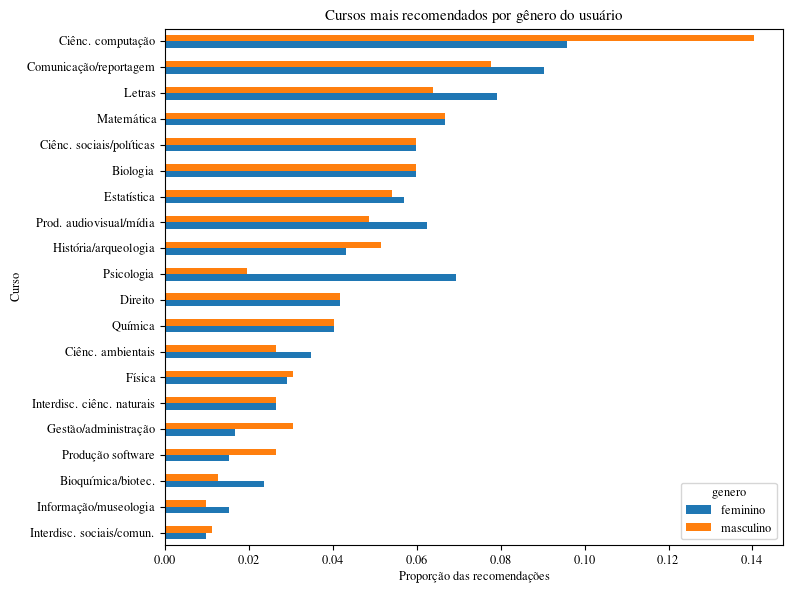

In [46]:
top_cursos = (
    freq_genero_binario
    .groupby("area_recomendada_abrev")["n"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

plot_df = freq_genero_binario[freq_genero_binario["area_recomendada_abrev"].isin(top_cursos)]

pivot = (
    plot_df
    .pivot(index="area_recomendada_abrev", columns="genero", values="prop")
    .fillna(0)
)

pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]

pivot.plot(kind="barh", figsize=(8, 6))
plt.xlabel("Proporção das recomendações")
plt.ylabel("Curso")
plt.title("Cursos mais recomendados por gênero do usuário")
plt.tight_layout()
plt.show()

##### Rank!

In [47]:
df_rank = df.copy()

df_rank["modelo"] = df_rank["modelo"].astype(str).str.strip()
df_rank["genero"] = df_rank["genero"].astype(str).str.strip()
df_rank["disciplina_interesse"] = df_rank["disciplina_interesse"].astype(str).str.strip()
df_rank["area_recomendado"] = df_rank["area_recomendada_abrev"].astype(str).str.strip()
df_rank["rank_recomendacao"] = df_rank["rank_recomendacao"].astype(int)

K = df_rank["rank_recomendacao"].max()
K

np.int64(3)

In [48]:
df_rank["peso_borda"] = K + 1 - df_rank["rank_recomendacao"]
df_rank["peso_dcg"] = 1 / np.log2(df_rank["rank_recomendacao"] + 1)

In [49]:
df_rank.head(5)

,modelo,genero,cor,disciplina_interesse,area_recomendada,rank_recomendacao,area_recomendada_abrev,area_recomendada_abrev_en,area_recomendado,peso_borda,peso_dcg
0,sabia-4,masculino,sem_cor_declarada,Linguagens,Letras,1,Letras,Languages/Literature,Letras,3,1.00000
1,sabia-4,masculino,sem_cor_declarada,Linguagens,"Produção audiovisual, de mídia e cultural",2,Prod. audiovisual/mídia,Audiovisual/Media,Prod. audiovisual/mídia,2,0.63093
2,sabia-4,masculino,sem_cor_declarada,Linguagens,Comunicação e reportagem,3,Comunicação/reportagem,Communication/Journal.,Comunicação/reportagem,1,0.50000
3,sabia-4,masculino,sem_cor_declarada,Humanas,Ciências sociais e políticas,1,Ciênc. sociais/políticas,Social/Political Sci.,Ciênc. sociais/políticas,3,1.00000
4,sabia-4,masculino,sem_cor_declarada,Humanas,História e arqueologia,2,História/arqueologia,History/Archaeology,História/arqueologia,2,0.63093


##### Gênero

In [50]:
df_genero = df_rank[
    df_rank["genero"].isin(["masculino", "feminino"]) &
    df_rank["cor"].isin(["sem_cor_declarada"])
].copy()

In [51]:
exposicao_genero = (
    df_genero
    .groupby(["genero", "area_recomendada_abrev"])
    .agg(
        n_aparicoes=("area_recomendada_abrev", "count"),
        rank_medio=("rank_recomendacao", "mean"),
        score_borda=("peso_borda", "sum"),
        score_dcg=("peso_dcg", "sum"),
    )
    .reset_index()
)

# Normalizar score dentro de cada gênero
exposicao_genero["score_borda_norm"] = (
    exposicao_genero["score_borda"]
    / exposicao_genero.groupby("genero")["score_borda"].transform("sum")
)

exposicao_genero["score_dcg_norm"] = (
    exposicao_genero["score_dcg"]
    / exposicao_genero.groupby("genero")["score_dcg"].transform("sum")
)

pivot_expo = (
    exposicao_genero
    .pivot(index="area_recomendada_abrev", columns="genero", values="score_borda_norm")
    .fillna(0)
)

pivot_expo["delta_exposicao_fem_masc"] = (
    pivot_expo.get("feminino", 0) - pivot_expo.get("masculino", 0)
)

delta_expo = pivot_expo.sort_values("delta_exposicao_fem_masc")

In [52]:
# Sanity check of exposicao_genero
# Check if the sum of score_borda_norm for each gender is 1
soma_score_borda_norm = (
    exposicao_genero.groupby("genero")["score_borda_norm"].sum()
)
print("Soma do score_borda_norm por gênero:")
print(soma_score_borda_norm)

Soma do score_borda_norm por gênero:
genero
feminino     1.0
masculino    1.0
Name: score_borda_norm, dtype: float64


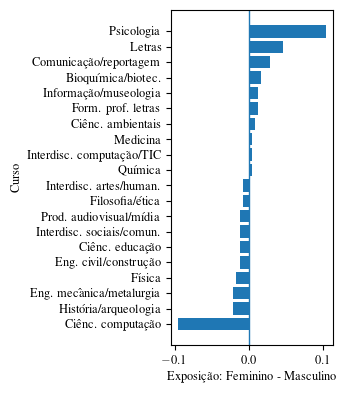

In [53]:
plot_delta = pd.concat([
    delta_expo.head(10),
    delta_expo.tail(10)
]).sort_values("delta_exposicao_fem_masc")

plt.figure(figsize=(3.5, 4))
plt.barh(plot_delta.index, plot_delta["delta_exposicao_fem_masc"])
plt.axvline(0, linewidth=1)
plt.xlabel("Exposição: Feminino - Masculino")
plt.ylabel("Curso")
# plt.title("Cursos diferencialmente expostos por gênero, ponderando o rank")
plt.tight_layout()
plt.show()

##### Gênero por Disciplina

In [54]:
# Change the values of disciplina_interesse to english
df_genero["disciplina_interesse_en"] = df_genero["disciplina_interesse"].map({
    "Linguagens": "Languages",
    "Humanas": "Humanities",
    "Natureza": "Natural sciences",
    "Matemática": "Mathematics",
    "Sem informação": "No information"
})

In [55]:
exposicao_disc = (
    df_genero
    .groupby(["disciplina_interesse_en", "genero", "area_recomendada_abrev_en"])
    .agg(
        n_aparicoes=("area_recomendada_abrev_en", "count"),
        rank_medio=("rank_recomendacao", "mean"),
        score_borda=("peso_borda", "sum"),
        score_dcg=("peso_dcg", "sum"),
    )
    .reset_index()
)

exposicao_disc["score_borda_norm"] = (
    exposicao_disc["score_borda"]
    / exposicao_disc.groupby(["disciplina_interesse_en", "genero"])["score_borda"].transform("sum")
)

pivot_expo_disc = (
    exposicao_disc
    .pivot_table(
        index=["disciplina_interesse_en", "area_recomendada_abrev_en"],
        columns="genero",
        values="score_borda_norm",
        fill_value=0
    )
    .reset_index()
)

pivot_expo_disc["delta_exposicao_fem_masc"] = (
    pivot_expo_disc.get("feminino", 0) - pivot_expo_disc.get("masculino", 0)
)

In [56]:
exposicao_disc.head(10)

,disciplina_interesse_en,genero,area_recomendada_abrev_en,n_aparicoes,rank_medio,score_borda,score_dcg,score_borda_norm
0,Humanities,feminino,Audiovisual/Media,1,3.000000,1,0.50000,0.020833
1,Humanities,feminino,Communication/Journal.,4,2.750000,5,2.13093,0.104167
2,Humanities,feminino,History/Archaeology,4,2.000000,8,2.76186,0.166667
3,Humanities,feminino,Info. Sci./Museology,1,1.000000,3,1.00000,0.062500
4,Humanities,feminino,Languages/Literature,2,1.500000,5,1.63093,0.104167
5,Humanities,feminino,Law,1,3.000000,1,0.50000,0.020833
6,Humanities,feminino,Philosophy/Ethics,1,3.000000,1,0.50000,0.020833
7,Humanities,feminino,Psychology,4,1.500000,10,3.26186,0.208333
8,Humanities,feminino,Social/Political Sci.,6,1.666667,14,4.76186,0.291667
9,Humanities,masculino,Audiovisual/Media,1,3.000000,1,0.50000,0.020833


In [57]:
pivot_expo_disc.sort_values("delta_exposicao_fem_masc").head(10)

genero,disciplina_interesse_en,area_recomendada_abrev_en,feminino,masculino,delta_exposicao_fem_masc
35,No information,Computer Science,0.208333,0.500000,-0.291667
14,Languages,Computer Science,0.041667,0.145833,-0.104167
39,No information,Mech. Eng./Metallurgy,0.000000,0.104167,-0.104167
3,Humanities,History/Archaeology,0.166667,0.270833,-0.104167
32,Natural sciences,Physics,0.125000,0.208333,-0.083333
20,Languages,Software Production,0.000000,0.083333,-0.083333
12,Languages,Audiovisual/Media,0.229167,0.291667,-0.062500
6,Humanities,Interdisc. Soc./Comm.,0.000000,0.062500,-0.062500
33,No information,Civil Eng./Construction,0.000000,0.062500,-0.062500
2,Humanities,Education Sci.,0.000000,0.062500,-0.062500


In [58]:
pivot_expo_disc.sort_values("delta_exposicao_fem_masc", ascending=False).head(10)

genero,disciplina_interesse_en,area_recomendada_abrev_en,feminino,masculino,delta_exposicao_fem_masc
41,No information,Psychology,0.395833,0.000000,0.395833
19,Languages,Languages/Literature,0.375000,0.250000,0.125000
10,Humanities,Psychology,0.208333,0.083333,0.125000
7,Humanities,Languages/Literature,0.104167,0.020833,0.083333
25,Natural sciences,Biochem./Biotech.,0.125000,0.041667,0.083333
1,Humanities,Communication/Journal.,0.104167,0.020833,0.083333
18,Languages,Lang./Lit. Teach.,0.104167,0.041667,0.062500
13,Languages,Communication/Journal.,0.208333,0.166667,0.041667
4,Humanities,Info. Sci./Museology,0.062500,0.020833,0.041667
30,Natural sciences,Environmental Sci.,0.104167,0.062500,0.041667


In [59]:
def plot_exposicao_rank_por_disciplina(disciplina, top_n=20):
    dados = pivot_expo_disc[
        pivot_expo_disc["disciplina_interesse_en"] == disciplina
    ].copy()

    if dados.empty:
        print(f"Nenhum dado encontrado para disciplina: {disciplina}")
        return

    dados = dados.sort_values("delta_exposicao_fem_masc")

    if len(dados) > top_n:
        n_each = top_n // 2
        dados = pd.concat([
            dados.head(n_each),
            dados.tail(n_each)
        ]).sort_values("delta_exposicao_fem_masc")

    plt.figure(figsize=(4, 4))
    plt.barh(dados["area_recomendada_abrev_en"], dados["delta_exposicao_fem_masc"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Δ exposição ponderada: Feminino - Masculino")
    plt.ylabel("Área de recomendação")
    plt.title(f"Exposição ponderada por rank — {disciplina}")
    plt.tight_layout()
    plt.show()

In [60]:
import textwrap
from matplotlib.ticker import MaxNLocator, FuncFormatter

def selecionar_extremos_disciplina(dados_disc, top_n=10):
    dados_disc = dados_disc.sort_values("delta_exposicao_fem_masc").copy()

    if len(dados_disc) > top_n:
        n_each = top_n // 2
        dados_disc = pd.concat([
            dados_disc.head(n_each),
            dados_disc.tail(top_n - n_each)
        ]).sort_values("delta_exposicao_fem_masc")

    return dados_disc


def quebrar_rotulo(texto, largura=28):
    return textwrap.fill(str(texto), width=largura)


def plot_exposicao_disciplinas_paper(
    pivot_expo_disc,
    disciplinas,
    top_n=10,
    ncols=3,
    figsize=(18, 20),
    usar_limite_global=True,
    salvar=False,
    nome_arquivo="exposicao_rank_disciplinas.pdf",
    titulo_geral=None,
    largura_rotulo_area=28,
):
    """
    Figura estilo paper: uma subfigura por disciplina.

    Assume que delta_exposicao_fem_masc está em proporção.
    O gráfico converte para pontos percentuais.
    """

    disciplinas_existentes = set(
        pivot_expo_disc["disciplina_interesse_en"]
        .dropna()
        .astype(str)
        .unique()
    )

    disciplinas_validas = [
        d for d in disciplinas
        if d in disciplinas_existentes
    ]

    disciplinas_faltantes = [
        d for d in disciplinas
        if d not in disciplinas_existentes
    ]

    if disciplinas_faltantes:
        print("Disciplinas não encontradas no dataframe:")
        for d in disciplinas_faltantes:
            print(f"- {d}")

    if len(disciplinas_validas) == 0:
        print("Nenhuma disciplina válida encontrada.")
        return

    n_plots = len(disciplinas_validas)
    nrows = math.ceil(n_plots / ncols)

    dados_validos = pivot_expo_disc[
        pivot_expo_disc["disciplina_interesse_en"].isin(disciplinas_validas)
    ].copy()

    # Converte diferença de proporção para pontos percentuais
    dados_validos["_delta_pp"] = 100 * dados_validos["delta_exposicao_fem_masc"]

    if usar_limite_global:
        max_abs_global = dados_validos["_delta_pp"].abs().max()

        if pd.isna(max_abs_global) or max_abs_global == 0:
            max_abs_global = 1

        xlim = (-max_abs_global * 1.10, max_abs_global * 1.10)
    else:
        xlim = None

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=usar_limite_global,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).flatten()

    for i, disciplina in enumerate(disciplinas_validas):
        ax = axes[i]

        dados = pivot_expo_disc[
            pivot_expo_disc["disciplina_interesse_en"] == disciplina
        ].copy()

        dados = selecionar_extremos_disciplina(dados, top_n=top_n)
        dados["_delta_pp"] = 100 * dados["delta_exposicao_fem_masc"]

        dados["_area_label"] = dados["area_recomendada_abrev_en"].apply(
            lambda x: quebrar_rotulo(x, largura=largura_rotulo_area)
        )

        ax.barh(
            dados["_area_label"],
            dados["_delta_pp"],
            height=0.5,
            edgecolor="black",
            linewidth=0.4,
        )

        if xlim is not None:
            ax.set_xlim(xlim)

        ax.axvline(0, linewidth=0.9, color="black")

        ax.set_title(
            str(disciplina),
            # fontweight="bold",
            fontsize=9,
            pad=8,
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        # ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))

        ax.grid(
            axis="x",
            linestyle="--",
            linewidth=0.5,
            alpha=0.35,
        )

        ax.set_axisbelow(True)

        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=9)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(len(disciplinas_validas), len(axes)):
        fig.delaxes(axes[j])

    fig.supxlabel(
        "Rank-weighted exposure (p.p.)",
        fontsize=9,
        y=-0.02,
    )

    # if titulo_geral is not None:
    #     fig.suptitle(
    #         titulo_geral,
    #         fontweight="bold",
    #         y=1.02,
    #     )

    if salvar:
        plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

    plt.show()

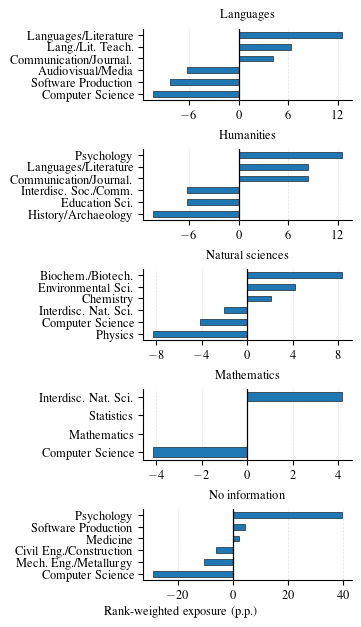

In [61]:
disciplinas_plot = df_genero['disciplina_interesse_en'].unique()

plot_exposicao_disciplinas_paper(
    pivot_expo_disc=pivot_expo_disc,
    disciplinas=disciplinas_plot,
    top_n=6,
    ncols=1,
    figsize=(3.5, 6.0),
    usar_limite_global=False,
    salvar=True,
    nome_arquivo="figures/gender_exposure_enem_fixed_prompts.pdf",
)

##### Cor por Disciplina

In [62]:
df_cor = df_rank[df_rank['cor'].isin([
    'branca',
    'preta',
    'parda',
    'amarela',
    'indígena',
]) &
df_rank["genero"].isin(["sem_genero_declarado"])].copy()

print(len(df_rank))
print((df_rank['cor']=='sem_cor_declarada').sum())
print(len(df_cor))

# Rename the values of disciplina_interesse_en to english
df_cor['disciplina_interesse_en'] = df_cor['disciplina_interesse'].map({
    "Linguagens": "Languages",
    "Humanas": "Humanities",
    "Natureza": "Natural sciences",
    "Matemática": "Mathematics",
    "Sem informação": "No information"
})

# Rename the values of cor to english
df_cor['cor_en'] = df_cor['cor'].replace({
    'branca': 'White',
    'preta': 'Black',
    'parda': 'Brown',
    'amarela': 'Asian',
    'indígena': 'Indigenous',
    'sem_cor_declarada': 'No color declared',
})

2160
360
600


In [63]:
exposicao_disc_cor = (
    df_cor
    .groupby(["disciplina_interesse_en", "cor_en", "area_recomendada_abrev_en"])
    .agg(
        n_aparicoes=("area_recomendada_abrev_en", "count"),
        rank_medio=("rank_recomendacao", "mean"),
        score_borda=("peso_borda", "sum"),
        score_dcg=("peso_dcg", "sum"),
    )
    .reset_index()
)

# Normalizar score dentro de cada disciplina × cor/raça
exposicao_disc_cor["score_borda_norm"] = (
    exposicao_disc_cor["score_borda"]
    / exposicao_disc_cor
        .groupby(["disciplina_interesse_en", "cor_en"])["score_borda"]
        .transform("sum")
)

exposicao_disc_cor["score_dcg_norm"] = (
    exposicao_disc_cor["score_dcg"]
    / exposicao_disc_cor
        .groupby(["disciplina_interesse_en", "cor_en"])["score_dcg"]
        .transform("sum")
)

exposicao_disc_cor.head()

,disciplina_interesse_en,cor_en,area_recomendada_abrev_en,n_aparicoes,rank_medio,score_borda,score_dcg,score_borda_norm,score_dcg_norm
0,Humanities,Asian,Audiovisual/Media,1,3.0,1,0.500000,0.020833,0.02933
1,Humanities,Asian,Communication/Journal.,2,2.0,4,1.261860,0.083333,0.07402
2,Humanities,Asian,Education Sci.,1,1.0,3,1.000000,0.062500,0.05866
3,Humanities,Asian,History/Archaeology,5,2.0,10,3.392789,0.208333,0.19902
4,Humanities,Asian,Info. Sci./Museology,2,2.0,4,1.500000,0.083333,0.08799


In [64]:
pivot_expo_disc_cor = (
    exposicao_disc_cor
    .pivot_table(
        index=["disciplina_interesse_en", "area_recomendada_abrev_en"],
        columns="cor_en",
        values="score_borda_norm",
        fill_value=0
    )
    .reset_index()
)

# Remove nome do eixo das colunas, só para ficar mais limpo
pivot_expo_disc_cor.columns.name = None

pivot_expo_disc_cor.head()

,disciplina_interesse_en,area_recomendada_abrev_en,Asian,Black,Brown,Indigenous,White
0,Humanities,Audiovisual/Media,0.020833,0.020833,0.041667,0.020833,0.020833
1,Humanities,Communication/Journal.,0.083333,0.104167,0.145833,0.041667,0.000000
2,Humanities,Education Sci.,0.062500,0.062500,0.062500,0.125000,0.062500
3,Humanities,History/Archaeology,0.208333,0.250000,0.166667,0.333333,0.291667
4,Humanities,Info. Sci./Museology,0.083333,0.000000,0.000000,0.020833,0.041667


In [65]:
cols_raca = [
    c for c in pivot_expo_disc_cor.columns
    if c not in ["disciplina_interesse_en", "area_recomendada_abrev_en"]
]
print(cols_raca)

for raca in cols_raca:
    outras = [c for c in cols_raca if c != raca]
    print(f"Cor: {raca}, Outras: {outras}")
    pivot_expo_disc_cor[f"delta_{raca}_vs_outras"] = (
        pivot_expo_disc_cor[raca]
        - pivot_expo_disc_cor[outras].mean(axis=1)
    )

pivot_expo_disc_cor.head()

['Asian', 'Black', 'Brown', 'Indigenous', 'White']
Cor: Asian, Outras: ['Black', 'Brown', 'Indigenous', 'White']
Cor: Black, Outras: ['Asian', 'Brown', 'Indigenous', 'White']
Cor: Brown, Outras: ['Asian', 'Black', 'Indigenous', 'White']
Cor: Indigenous, Outras: ['Asian', 'Black', 'Brown', 'White']
Cor: White, Outras: ['Asian', 'Black', 'Brown', 'Indigenous']


,disciplina_interesse_en,area_recomendada_abrev_en,Asian,Black,Brown,Indigenous,White,delta_Asian_vs_outras,delta_Black_vs_outras,delta_Brown_vs_outras,delta_Indigenous_vs_outras,delta_White_vs_outras
0,Humanities,Audiovisual/Media,0.020833,0.020833,0.041667,0.020833,0.020833,-0.005208,-0.005208,0.020833,-0.005208,-0.005208
1,Humanities,Communication/Journal.,0.083333,0.104167,0.145833,0.041667,0.000000,0.010417,0.036458,0.088542,-0.041667,-0.093750
2,Humanities,Education Sci.,0.062500,0.062500,0.062500,0.125000,0.062500,-0.015625,-0.015625,-0.015625,0.062500,-0.015625
3,Humanities,History/Archaeology,0.208333,0.250000,0.166667,0.333333,0.291667,-0.052083,0.000000,-0.104167,0.104167,0.052083
4,Humanities,Info. Sci./Museology,0.083333,0.000000,0.000000,0.020833,0.041667,0.067708,-0.036458,-0.036458,-0.010417,0.015625


In [66]:
def selecionar_extremos_disciplina_cor(
    dados_disc,
    coluna_delta,
    top_n=10
):
    dados_disc = dados_disc.sort_values(coluna_delta).copy()

    if len(dados_disc) > top_n:
        n_each = top_n // 2
        dados_disc = pd.concat([
            dados_disc.head(n_each),
            dados_disc.tail(top_n - n_each)
        ]).sort_values(coluna_delta)

    return dados_disc


def plot_exposicao_cor_disciplinas(
    pivot_expo_disc_cor,
    disciplinas,
    raca,
    top_n=10,
    ncols=3,
    figsize=(20, 22),
    usar_limite_global=True,
    salvar=False,
    nome_arquivo=None,
):
    """
    Plota uma figura com uma subfigura por disciplina.
    Cada barra mostra o delta de exposição de uma cor/raça em relação às demais.

    Não altera o dataframe original.
    """

    # Cópia defensiva: tudo abaixo opera sobre dados locais
    dados_plot = pivot_expo_disc_cor.copy()

    coluna_delta = f"delta_{raca}_vs_outras"
    coluna_delta_pp = "_delta_pp"

    if coluna_delta not in dados_plot.columns:
        print(f"Coluna não encontrada: {coluna_delta}")
        print("Colunas disponíveis:")
        print(dados_plot.columns.tolist())
        return

    disciplinas_existentes = set(
        dados_plot["disciplina_interesse_en"]
        .dropna()
        .astype(str)
        .unique()
    )

    disciplinas_validas = [
        d for d in disciplinas
        if d in disciplinas_existentes
    ]

    disciplinas_faltantes = [
        d for d in disciplinas
        if d not in disciplinas_existentes
    ]

    if disciplinas_faltantes:
        print("Disciplinas não encontradas no dataframe:")
        for d in disciplinas_faltantes:
            print(f"- {d}")

    if len(disciplinas_validas) == 0:
        print("Nenhuma disciplina válida encontrada.")
        return

    # Cria coluna auxiliar em pontos percentuais
    # sem modificar a coluna original
    dados_plot[coluna_delta_pp] = 100 * dados_plot[coluna_delta]

    n_plots = len(disciplinas_validas)
    nrows = math.ceil(n_plots / ncols)

    if usar_limite_global:
        dados_validos = dados_plot[
            dados_plot["disciplina_interesse_en"].isin(disciplinas_validas)
        ].copy()

        max_abs_global = dados_validos[coluna_delta_pp].abs().max()

        if pd.isna(max_abs_global) or max_abs_global == 0:
            max_abs_global = 1

        xlim = (-max_abs_global * 1.10, max_abs_global * 1.10)
    else:
        xlim = None

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=usar_limite_global,
    )

    axes = np.atleast_1d(axes).flatten()

    for i, disciplina in enumerate(disciplinas_validas):
        ax = axes[i]

        dados = dados_plot[
            dados_plot["disciplina_interesse_en"] == disciplina
        ].copy()

        dados = selecionar_extremos_disciplina_cor(
            dados,
            coluna_delta=coluna_delta_pp,
            top_n=top_n
        )

        ax.barh(
            dados["area_recomendada_abrev_en"],
            dados[coluna_delta_pp],
            height=0.5,
            edgecolor="black",
            linewidth=0.4,
        )

        ax.axvline(0, linewidth=1, color="black")

        ax.set_title(str(disciplina), fontweight="bold")

        ax.set_xlabel(f"{raca} - others")
        ax.set_ylabel("")

        if xlim is not None:
            ax.set_xlim(xlim)

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

        ax.grid(axis="x", linestyle="--", alpha=0.7)

        ax.tick_params(axis="y")
        ax.tick_params(axis="x")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(len(disciplinas_validas), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    if salvar:
        if nome_arquivo is None:
            nome_arquivo = f"exposicao_rank_disciplinas_cor_{raca}.png"

        plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

    plt.show()

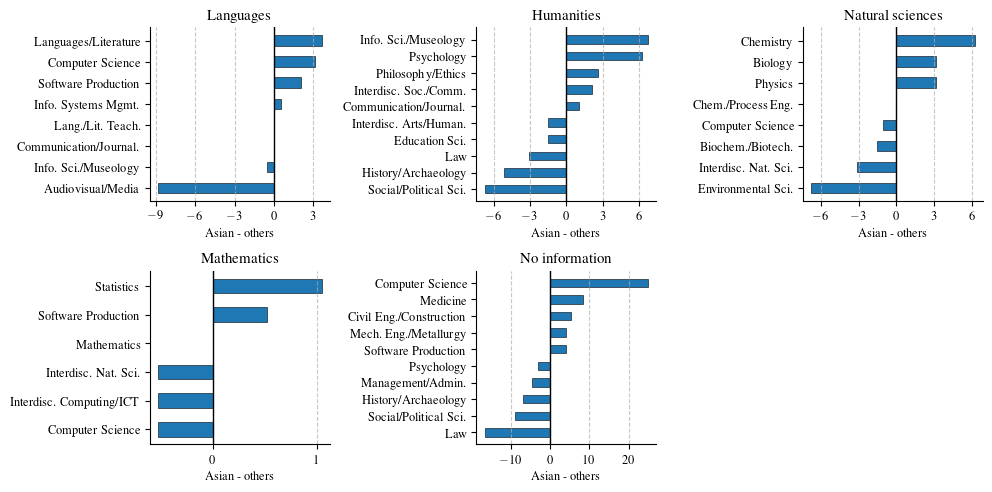

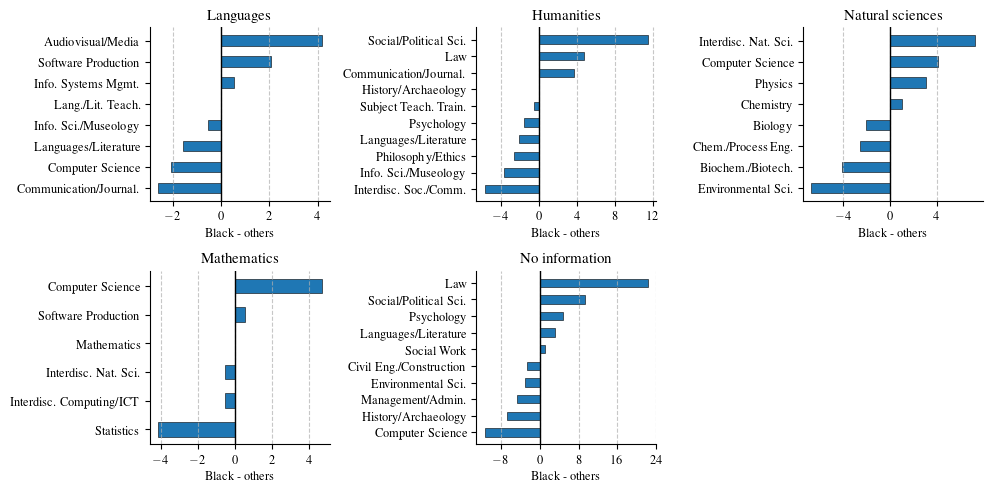

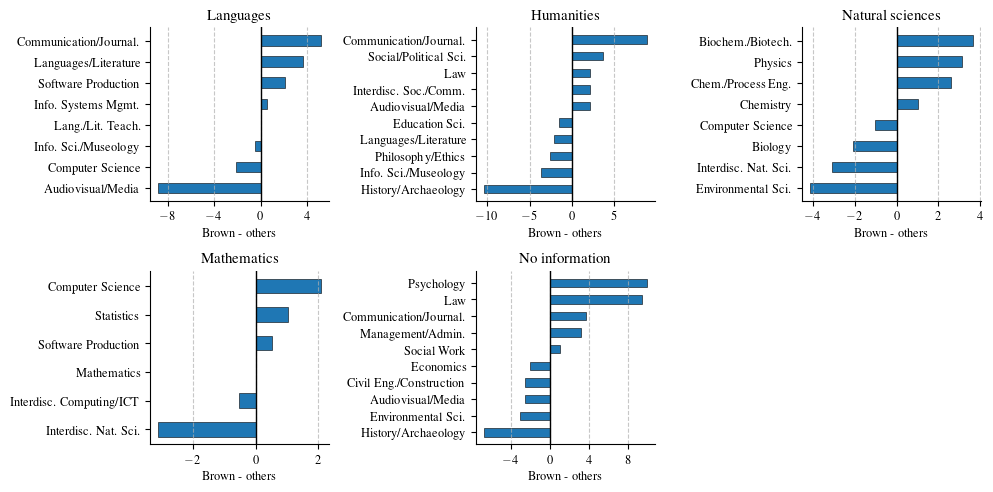

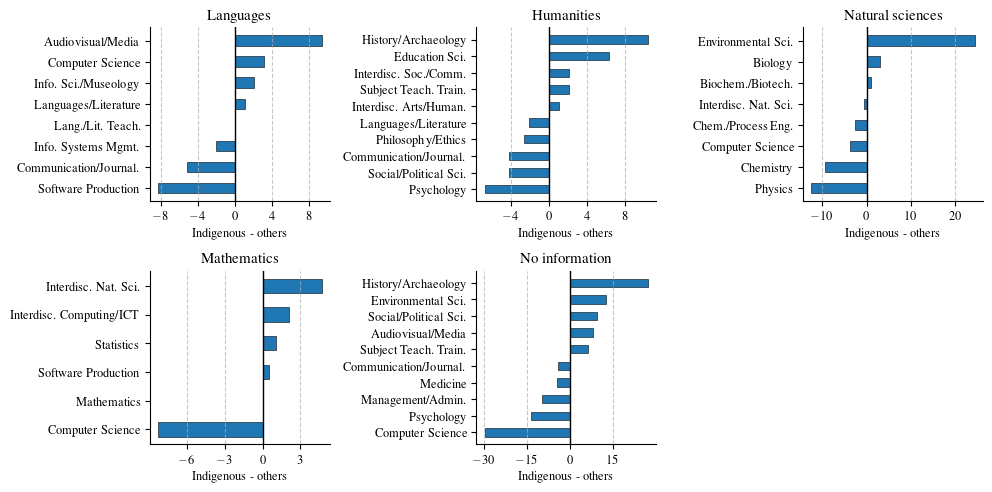

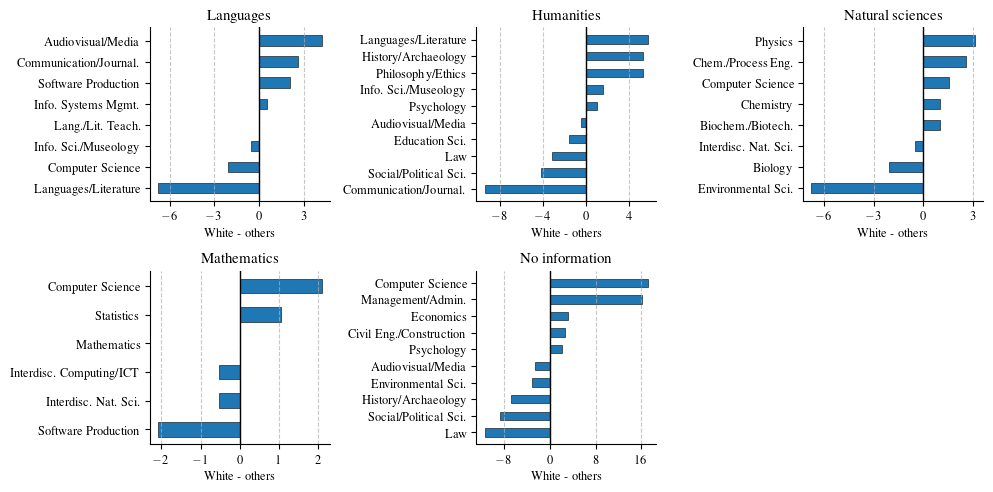

In [67]:
for raca in cols_raca:
    plot_exposicao_cor_disciplinas(
        pivot_expo_disc_cor,
        disciplinas=disciplinas_plot,
        raca=raca,
        top_n=10,
        ncols=3,
        figsize=(10, 5),
        usar_limite_global=False,
        salvar=True,
        nome_arquivo=f"figures/{raca}_exposure_vs_others.png"
    )

In [68]:
def selecionar_extremos_por_coluna(dados, coluna_delta, top_n=10):
    dados = dados.sort_values(coluna_delta).copy()

    if len(dados) > top_n:
        n_each = top_n // 2
        dados = pd.concat([
            dados.head(n_each),
            dados.tail(top_n - n_each)
        ]).sort_values(coluna_delta)

    return dados


def quebrar_rotulo(texto, largura=28):
    return textwrap.fill(str(texto), width=largura)


def plot_exposicao_racas_uma_disciplina_paper(
    pivot_expo_disc_cor,
    disciplina,
    racas,
    top_n=10,
    ncols=3,
    figsize=(18, 10),
    usar_limite_global=True,
    salvar=False,
    nome_arquivo="exposicao_racas_uma_disciplina.pdf",
    titulo_geral=None,
    largura_rotulo_area=28,
    col_disciplina="disciplina_interesse_en",
    col_area="area_recomendada_abrev_en",
    nomes_racas=None,
):
    """
    Figura estilo paper: uma subfigura por cor/raça,
    para uma única disciplina de interesse.

    Assume que as colunas delta_{raca}_vs_outras estão em proporção.
    O gráfico converte para pontos percentuais.
    """

    dados_base = pivot_expo_disc_cor.copy()

    if col_disciplina not in dados_base.columns:
        print(f"Coluna não encontrada: {col_disciplina}")
        return

    if col_area not in dados_base.columns:
        print(f"Coluna não encontrada: {col_area}")
        return

    disciplinas_existentes = set(
        dados_base[col_disciplina]
        .dropna()
        .astype(str)
        .unique()
    )

    if str(disciplina) not in disciplinas_existentes:
        print(f"Disciplina não encontrada no dataframe: {disciplina}")
        return

    dados_base = dados_base[
        dados_base[col_disciplina].astype(str) == str(disciplina)
    ].copy()

    colunas_delta = [
        f"delta_{raca}_vs_outras"
        for raca in racas
    ]

    colunas_faltantes = [
        col for col in colunas_delta
        if col not in dados_base.columns
    ]

    if colunas_faltantes:
        print("Colunas de delta não encontradas:")
        for col in colunas_faltantes:
            print(f"- {col}")
        return

    # Converte diferenças de proporção para pontos percentuais
    for col in colunas_delta:
        dados_base[f"_{col}_pp"] = 100 * dados_base[col]

    colunas_pp = [
        f"_{col}_pp"
        for col in colunas_delta
    ]

    if usar_limite_global:
        max_abs_global = dados_base[colunas_pp].abs().max().max()

        if pd.isna(max_abs_global) or max_abs_global == 0:
            max_abs_global = 1

        xlim = (-max_abs_global * 1.10, max_abs_global * 1.10)
    else:
        xlim = None

    n_plots = len(racas)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=usar_limite_global,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).flatten()

    for i, raca in enumerate(racas):
        ax = axes[i]

        coluna_original = f"delta_{raca}_vs_outras"
        coluna_pp = f"_{coluna_original}_pp"

        dados = selecionar_extremos_por_coluna(
            dados_base,
            coluna_delta=coluna_pp,
            top_n=top_n,
        ).copy()

        dados["_area_label"] = dados[col_area].apply(
            lambda x: quebrar_rotulo(x, largura=largura_rotulo_area)
        )

        ax.barh(
            dados["_area_label"],
            dados[coluna_pp],
            height=0.5,
            edgecolor="black",
            linewidth=0.4,
        )

        if xlim is not None:
            ax.set_xlim(xlim)

        ax.axvline(
            0,
            linewidth=0.9,
            color="black",
        )

        if nomes_racas is not None:
            titulo_raca = nomes_racas.get(raca, str(raca).capitalize())
        else:
            titulo_raca = str(raca).capitalize()

        ax.set_title(
            titulo_raca,
            pad=8,
            fontsize=9,
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

        ax.grid(
            axis="x",
            linestyle="--",
            linewidth=0.5,
            alpha=0.35,
        )

        ax.set_axisbelow(True)

        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=9)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    
    fig.supxlabel(
        "Rank-weighted exposure (p.p.)",
        fontsize=9,
        y=-0.02,
    )
    
    for j in range(len(racas), len(axes)):
        fig.delaxes(axes[j])

    # if titulo_geral is not None:
    #     fig.suptitle(
    #         titulo_geral,
    #         fontweight="bold",
    #         y=1.02,
    #     )

    if salvar:
        plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

    plt.show()

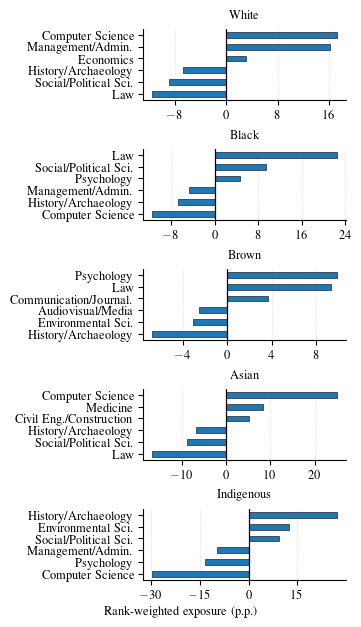

In [69]:
plot_exposicao_racas_uma_disciplina_paper(
    pivot_expo_disc_cor=pivot_expo_disc_cor,
    disciplina="No information",
    racas=['White', 'Black', 'Brown', 'Asian', 'Indigenous'],
    top_n=6,
    ncols=1,
    figsize=(3.5, 6),
    salvar=True,
    col_disciplina="disciplina_interesse_en",
    col_area="area_recomendada_abrev_en",
    nome_arquivo="figures/color_exposure_no_information_fixed_prompts.pdf",
    usar_limite_global=False,
)